# Preprocessing the data of scRNA-seq with omicverse[CPU-GPU-mixed]

The count table, a numeric matrix of genes × cells, is the basic input data structure in the analysis of single-cell RNA-sequencing data. A common preprocessing step is to adjust the counts for variable sampling efficiency and to transform them so that the variance is similar across the dynamic range. 

Suitable methods to preprocess the scRNA-seq is important. Here, we introduce some preprocessing step to help researchers can perform downstream analysis easyier.

User can compare our tutorial with [scanpy'tutorial](https://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html) to learn how to use omicverse well

Colab_Reproducibility：https://colab.research.google.com/drive/1DXLSls_ppgJmAaZTUvqazNC_E7EDCxUe?usp=sharing

In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set(font_path='Arial')

# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



:::{note}
“When OmicVerse is upgraded to version > 1.7.0, it supports CPU–GPU mixed acceleration without requiring `rapids_singlecell` as a dependency—enjoy faster single-cell analysis!”
:::


In [2]:
ov.settings.cpu_gpu_mixed_init()

CPU-GPU mixed mode activated
Available GPU accelerators: CUDA


Load the PBMC 8k 10x dataset bundled with omicverse (`ov.datasets.pbmc8k()` downloads on first call, then caches):

In [3]:
# Load PBMC 8k from omicverse's bundled datasets
adata = ov.datasets.pbmc8k()
adata.var_names_make_unique()
adata.obs_names_make_unique()
adata

🩸 Downloading PBMC 8k dataset
Using Stanford mirror for pbmc8k
⚠️ File ./data/pbmc8k.h5ad already exists
 Loading data from ./data/pbmc8k.h5ad


✅ Successfully loaded: 7750 cells × 20939 genes


AnnData object with n_obs × n_vars = 7750 × 20939
    obs: 'kit', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'predicted_celltype', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_name', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    obsm: 'UMAP', 'X_pca', 'X_umap'

## Preprocessing

### Quantity control

For single-cell data, we require quality control prior to analysis, including the removal of cells containing double cells, low-expressing cells, and low-expressing genes. In addition to this, we need to filter based on mitochondrial gene ratios, number of transcripts, number of genes expressed per cell, cellular Complexity, etc. For a detailed description of the different QCs please see the document: https://hbctraining.github.io/scRNA-seq/lessons/04_SC_quality_control.html

:::{note}
if the version of `omicverse` larger than `1.6.4`, the `doublets_method` can be set between `scrublet` and `sccomposite`.
:::

COMPOSITE (COMpound POiSson multIplet deTEction model) is a computational tool for multiplet detection in both single-cell single-omics and multiomics settings. It has been implemented as an automated pipeline and is available as both a cloud-based application with a user-friendly interface and a Python package.

Hu, H., Wang, X., Feng, S. et al. A unified model-based framework for doublet or multiplet detection in single-cell multiomics data. Nat Commun 15, 5562 (2024). https://doi.org/10.1038/s41467-024-49448-x

In [4]:
%%time
adata=ov.pp.qc(
    adata,
    tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
    doublets_method='scrublet',
    batch_key=None,
    filter_doublets=True,
)
adata

⚙️ Using CPU/GPU mixed mode for QC...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA H100 80GB HBM3
    ------------------------------ 1109/81559 MiB (1.4%)

🔍 Quality Control Analysis (CPU-GPU Mixed):
   Dataset shape: 7,750 cells × 20,939 genes
   QC mode: seurat
   Doublet detection: scrublet
   Auto-detected mitochondrial prefix: 'MT-'
   Mitochondrial genes: MT-

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 99                 │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin        

   ✓ Final filtering: 0 cells, 10 genes removed

🔍 Step 4: Doublet Detection
   ⚠️  Note: 'scrublet' detection is legacy and may not work optimally
   💡 Consider using 'doublets_method=scdblfinder' (default) for better results
   🔍 Running scrublet doublet detection...

🔍 Running Scrublet Doublet Detection:
   Mode: cpu-gpu-mixed
   Computing doublet prediction using Scrublet algorithm
   🔍 Filtering genes and cells...
🔍 Filtering genes...
   Parameters: min_cells≥3


   ✓ Filtered: 0 genes removed
🔍 Filtering cells...
   Parameters: min_genes≥3


   ✓ Filtered: 0 cells removed
   🔍 Normalizing data and selecting highly variable genes...

🔍 Count Normalization:
   Target sum: median
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 7,698 cells × 20,929 genes
   ✓ Runtime: 0.05s



🔍 Highly Variable Genes Selection:
   Method: seurat


...

   🔍 Normalizing observed and simulated data...

🔍 Count Normalization:
   Target sum: 1000000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 7,698 cells × 1,837 genes
   ✓ Runtime: 0.00s

🔍 Count Normalization:
   Target sum: 1000000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 15,396 cells × 1,837 genes
   ✓ Runtime: 0.04s


   🔍 Embedding transcriptomes using PCA...

Using CUDA device: NVIDIA H100 80GB HBM3
✅ Using built-in torch_pca for GPU-accelerated PCA
   🚀 Using torch_pca PCA for CUDA GPU acceleration in scrublet
   🚀 torch_pca PCA backend: CUDA GPU acceleration (scrublet, supports sparse)
   📊 Scrublet PCA input data type - X_obs: ndarray, shape: (7698, 1837), dtype: float64
   📊 Scrublet PCA input data type - X_sim: ndarray, shape: (15396, 1837), dtype: float64


   🔍 Calculating doublet scores...


   🔍 Calling doublets with threshold detection...
   📊 Automatic threshold: 0.438
   📈 Detected doublet rate: 0.3%
   🔍 Detectable doublet fraction: 36.0%
   📊 Overall doublet rate comparison:
     • Expected: 5.0%
     • Estimated: 0.8%

✅ Scrublet Analysis Completed Successfully!
   ✓ Results added to AnnData object:
     • 'doublet_score': Doublet scores (adata.obs)
     • 'predicted_doublet': Boolean predictions (adata.obs)
     • 'scrublet': Parameters and metadata (adata.uns)
   ✓ Scrublet completed: 21 doublets removed (0.3%)

╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 4.5478s                                                 │
│  Shape:    7,750 x 20,939 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (f

AnnData object with n_obs × n_vars = 7677 × 20929
    obs: 'kit', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'predicted_celltype', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'passing_qc_step1', 'doublet_score', 'predicted_doublet'
    var: 'gene_name', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mt', 'ribo', 'hb'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance'
    obsm: 'UMAP', 'X_pca', 'X_umap'

### Alternative doublet backend — py-DoubletFinder

Besides `scrublet` and `sccomposite`, `ov.pp.qc` now supports `doublets_method='doubletfinder'` — a pure-Python port of the canonical R `DoubletFinder` (McGinnis et al., *Cell Systems* 2019). Same pANN algorithm, bit-for-bit reproducibility against R on matching PCA inputs, and typically faster on the pANN kernel thanks to `scipy.spatial.distance.cdist` + `np.argpartition` top-k.

```bash
pip install pydoubletfinder
```

Using it is a one-line switch of `doublets_method`:


In [ ]:
%%time
adata_df = ov.pp.qc(
    adata.copy(),
    tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
    doublets_method='doubletfinder',   # ← new backend (install: pip install pydoubletfinder)
    batch_key=None,
    filter_doublets=True,
)
print(adata_df)
print("doublet score column:", [c for c in adata_df.obs.columns if 'doublet' in c][:5])

### Alternative doublet backend — py-scDblFinder

`ov.pp.qc` also supports `doublets_method='scdblfinder'` — a pure-Python port of the R [scDblFinder](https://github.com/plger/scDblFinder) package (Germain et al., *F1000Research* 2022). This uses an xgboost classifier on kNN + cxds features, which is a complementary paradigm to scrublet (neighbor-fraction) and DoubletFinder (pANN).

```bash
pip install pyscdblfinder
```

Classification agreement with the R reference on pbmc3k is ~96%; see the [pyscdblfinder README](https://github.com/omicverse/py-scDblFinder#relationship-to-r-scdblfinder--what-matches-what-cant) for why cross-language xgboost scores can't be bit-for-bit identical.


In [ ]:
%%time
adata_scdbl = ov.pp.qc(
    adata.copy(),
    tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
    doublets_method='scdblfinder',   # ← new backend (install: pip install pyscdblfinder)
    batch_key=None,
    filter_doublets=True,
)
print(adata_scdbl)
print("score column:", [c for c in adata_scdbl.obs.columns if 'doublet' in c.lower() or 'scdbl' in c.lower()][:5])

### High variable Gene Detection

Here we try to use Pearson's method to calculate highly variable genes. This is the method that is proposed to be superior to ordinary normalisation. See [Article](https://www.nature.com/articles/s41592-023-01814-1#MOESM3) in *Nature Method* for details.


normalize|HVGs：We use | to control the preprocessing step, | before for the normalisation step, either `shiftlog` or `pearson`, and | after for the highly variable gene calculation step, either `pearson` or `seurat`. Our default is `shiftlog|pearson`.

- if you use `mode`=`shiftlog|pearson` you need to set `target_sum=50*1e4`, more people like to se `target_sum=1e4`, we test the result think 50*1e4 will be better
- if you use `mode`=`pearson|pearson`, you don't need to set `target_sum`

:::{note}
if the version of `omicverse` lower than `1.4.13`, the mode can only be set between `scanpy` and `pearson`.
:::


In [5]:
%%time
adata=ov.pp.preprocess(
    adata,mode='shiftlog|pearson',n_HVGs=2000,
    target_sum=50*1e4,identify_robust=True,
)
adata

🔍 [2026-04-20 17:29:41] Running preprocessing in 'cpu-gpu-mixed' mode...
Begin robust gene identification


    After filtration, 20929/20929 genes are kept.
    Among 20929 genes, 20050 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson



🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['IGLV3-21']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 7,677 cells × 20,050 genes
   ✓ Runtime: 0.53s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 20,050 total (10.0%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 1.70 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

AnnData object with n_obs × n_vars = 7677 × 20050
    obs: 'kit', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'predicted_celltype', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'passing_qc_step1', 'doublet_score', 'predicted_doublet'
    var: 'gene_name', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'statu

You can use `recover_counts` to recover the raw counts after normalize and log1p

In [6]:
adata[:,'CD3D'].to_df().T

      TGAGCCGTCGATAGAA-1_10X_5-rep1  TACACGACAGGACGTA-1_10X_5-rep1  \
gene                                                                 
CD3D                            0.0                            0.0   

      GAAGCAGCAGCTGTGC-1_10X_5-rep1  CTCACACAGAGCCCAA-1_10X_5-rep1  \
gene                                                                 
CD3D                            0.0                       6.131753   

      CTCGTCAGTGATAAAC-1_10X_5-rep1  TGTATTCTCAGCGATT-1_10X_5-rep1  \
gene                                                                 
CD3D                            0.0                       5.498595   

      GTTACAGCAGCTCGAC-1_10X_5-rep1  GTTAAGCGTCTGGAGA-1_10X_5-rep1  \
gene                                                                 
CD3D                            0.0                            0.0   

      TTGGCAAAGCCGTCGT-1_10X_5-rep1  CCTTCCCGTCTAGTGT-1_10X_5-rep1  ...  \
gene                                                                ...   
CD3D  

In [7]:
adata[:,'CD3D'].to_df(layer='counts').T

      TGAGCCGTCGATAGAA-1_10X_5-rep1  TACACGACAGGACGTA-1_10X_5-rep1  \
gene                                                                 
CD3D                            0.0                            0.0   

      GAAGCAGCAGCTGTGC-1_10X_5-rep1  CTCACACAGAGCCCAA-1_10X_5-rep1  \
gene                                                                 
CD3D                            0.0                            4.0   

      CTCGTCAGTGATAAAC-1_10X_5-rep1  TGTATTCTCAGCGATT-1_10X_5-rep1  \
gene                                                                 
CD3D                            0.0                            3.0   

      GTTACAGCAGCTCGAC-1_10X_5-rep1  GTTAAGCGTCTGGAGA-1_10X_5-rep1  \
gene                                                                 
CD3D                            0.0                            0.0   

      TTGGCAAAGCCGTCGT-1_10X_5-rep1  CCTTCCCGTCTAGTGT-1_10X_5-rep1  ...  \
gene                                                                ...   
CD3D  

In [8]:
X_counts_recovered, size_factors_sub=ov.pp.recover_counts(adata.X, 50*1e4, 50*1e5, log_base=None, 
                                                          chunk_size=10000)
adata.layers['recover_counts']=X_counts_recovered
adata[:,'CD3D'].to_df(layer='recover_counts').T

  0%|                                                                                                       | 0/7677 [00:00<?, ?it/s]

  1%|█▏                                                                                         | 103/7677 [00:00<00:07, 1020.14it/s]

  3%|██▍                                                                                        | 206/7677 [00:00<00:07, 1017.99it/s]

  4%|███▋                                                                                       | 308/7677 [00:00<00:07, 1018.02it/s]

  5%|████▊                                                                                      | 410/7677 [00:00<00:07, 1013.62it/s]

...

 97%|███████████████████████████████████████████████████████████████████████████████████████▍  | 7456/7677 [00:07<00:00, 1016.46it/s]

 98%|████████████████████████████████████████████████████████████████████████████████████████▌ | 7558/7677 [00:07<00:00, 1016.11it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████▊| 7660/7677 [00:07<00:00, 1015.81it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████| 7677/7677 [00:07<00:00, 1014.45it/s]

      TGAGCCGTCGATAGAA-1_10X_5-rep1  TACACGACAGGACGTA-1_10X_5-rep1  \
gene                                                                 
CD3D                              0                              0   

      GAAGCAGCAGCTGTGC-1_10X_5-rep1  CTCACACAGAGCCCAA-1_10X_5-rep1  \
gene                                                                 
CD3D                              0                              3   

      CTCGTCAGTGATAAAC-1_10X_5-rep1  TGTATTCTCAGCGATT-1_10X_5-rep1  \
gene                                                                 
CD3D                              0                              2   

      GTTACAGCAGCTCGAC-1_10X_5-rep1  GTTAAGCGTCTGGAGA-1_10X_5-rep1  \
gene                                                                 
CD3D                              0                              0   

      TTGGCAAAGCCGTCGT-1_10X_5-rep1  CCTTCCCGTCTAGTGT-1_10X_5-rep1  ...  \
gene                                                                ...   
CD3D  

Set the .raw attribute of the AnnData object to the normalized and logarithmized raw gene expression for later use in differential testing and visualizations of gene expression. This simply freezes the state of the AnnData object.

In [9]:
%%time
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
adata

CPU times: user 36.4 ms, sys: 27.1 ms, total: 63.5 ms
Wall time: 63.5 ms


View of AnnData object with n_obs × n_vars = 7677 × 2000
    obs: 'kit', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'predicted_celltype', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'passing_qc_step1', 'doublet_score', 'predicted_doublet'
    var: 'gene_name', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status',

## Principal component analysis

In contrast to scanpy, we do not directly scale the variance of the original expression matrix, but store the results of the variance scaling in the layer, due to the fact that scale may cause changes in the data distribution, and we have not found scale to be meaningful in any scenario other than a principal component analysis

In [10]:
%%time
ov.pp.scale(adata)
adata


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.7377s                                                 │
│  Shape:    7,677 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 7677x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
CPU times: user 591 ms, sys: 207 ms, total: 798 ms
Wall time: 740 ms


AnnData object with n_obs × n_vars = 7677 × 2000
    obs: 'kit', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'predicted_celltype', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'passing_qc_step1', 'doublet_score', 'predicted_doublet'
    var: 'gene_name', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status

If you want to perform pca in normlog layer, you can set `layer`=`normlog`, but we think scaled is necessary in PCA.

In [11]:
%%time
ov.pp.pca(adata,layer='scaled',n_pcs=50)
adata

🚀 Using GPU to calculate PCA...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA H100 80GB HBM3
    |----------------------------- 2889/81559 MiB (3.5%)
computing PCA🔍


    with n_comps=50



Using CUDA device: NVIDIA H100 80GB HBM3
✅ Using built-in torch_pca for GPU-accelerated PCA
   🚀 Using torch_pca PCA for CUDA GPU acceleration
   🚀 torch_pca PCA backend: CUDA GPU acceleration (supports sparse matrices)
   📊 PCA input data type: ArrayView, shape: (7677, 2000), dtype: float64
   🔧 solver_used_in_uns (planned): covariance_eigh


   🔧 PCA solver used: covariance_eigh
    finished✅ (0.36s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 0.3821s                                                 │
│  Shape:    7,677 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 7677x50)               │
│                                                                    │
╰─────────

AnnData object with n_obs × n_vars = 7677 × 2000
    obs: 'kit', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'predicted_celltype', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'passing_qc_step1', 'doublet_score', 'predicted_doublet'
    var: 'gene_name', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status

X_pca converted to PCA to visualize and saved to adata.obsm['PCA']
if you want to use X_pca, please set convert=False


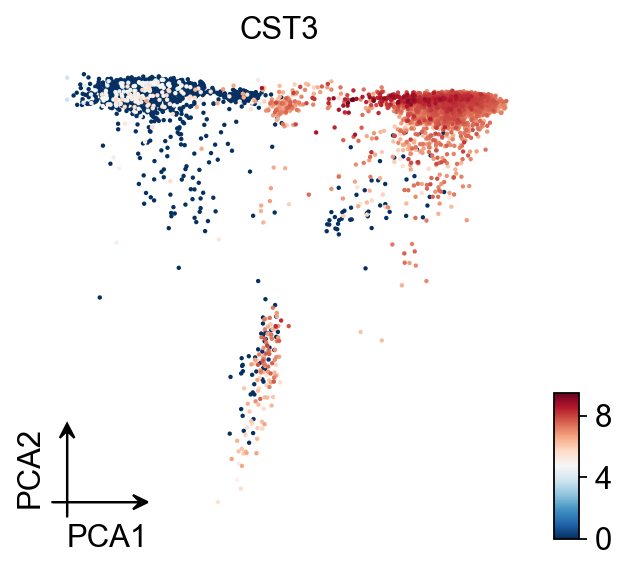

In [12]:
adata.obsm['X_pca']=adata.obsm['scaled|original|X_pca']
ov.pl.pca(adata,color='CST3')

## Embedding the neighborhood graph

We suggest embedding the graph in two dimensions using UMAP (McInnes et al., 2018), see below. It is potentially more faithful to the global connectivity of the manifold than tSNE, i.e., it better preserves trajectories. In some ocassions, you might still observe disconnected clusters and similar connectivity violations. They can usually be remedied by running:

In [13]:
%%time
ov.pp.neighbors(adata, n_neighbors=15, n_pcs=50,
               use_rep='scaled|original|X_pca')

🚀 Using torch CPU/GPU mixed mode to calculate neighbors...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA H100 80GB HBM3
    |----------------------------- 2891/81559 MiB (3.5%)
🚀 Mixed mode default transformer: pyg

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu-gpu-mixed
   Neighbors: 15
   Method: torch
   Metric: euclidean
   Transformer: pyg
   Representation: scaled|original|X_pca
   PCs used: 50
   🔍 Computing neighbor distances...
   💡 Using PyTorch Geometric KNN on cuda
   🔍 Computing connectivity matrix...
   💡 Using GPU-optimized connectivity computation


   Using device: cuda
   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 7,677 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 6.4226s                                                 │
│  Shape:    7,677 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'torch', 'random_...│
│                                                                    │
│  ● 

### UMAP
You also can use `umap` to visualize the neighborhood graph

In [14]:
%%time
ov.pp.umap(adata)

🔍 [2026-04-20 17:30:03] Running UMAP in 'cpu-gpu-mixed' mode...
🚀 Using torch GPU to calculate UMAP...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA H100 80GB HBM3
    |----------------------------- 2899/81559 MiB (3.6%)

🔍 UMAP Dimensionality Reduction:
   Mode: cpu-gpu-mixed
   Method: pumap
   Components: 2
   Min distance: 0.5
{'n_neighbors': 15, 'method': 'torch', 'random_state': 0, 'metric': 'euclidean', 'use_rep': 'scaled|original|X_pca', 'n_pcs': 50}
   ⚠️ Connectivities matrix was not computed with UMAP method
   🔍 Computing UMAP parameters...
   🔍 Computing UMAP embedding (Parametric PyTorch method)...
   Using device: cuda
   Dataset: 7677 samples × 50 features
   Batch size: 16384
   Learning rate: 0.001
   Total graph passes: 500 (split into 4 training epochs)
   Training parametric UMAP model...
🚀 Parametric UMAP Training
📊 Device: cuda
📈 Data shape: torch.Size([7677, 50])
🔗 Building UMAP graph...
♻️  Reusing cached GPU fuzzy graph (171174 edges)
🔢 Edge-SGD plan: 500 graph


🏋️  Starting Training...
────────────────────────────────────────────────────────────


Training:   0%|                                                                                                       | 0/4 [00:00<?]

Training:   0%|                                                                                                       | 0/4 [00:01<?]

Training:   0%|                                                                                                       | 0/4 [00:01<?]

...

Training:  75%|██████████████████████████████████████████████████████████████████████████▎                        | 3/4 [00:04<00:01]

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:04<00:00]

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:04<00:00]

✓ New best loss: 0.1836

────────────────────────────────────────────────────────────
✅ Training Completed!
📉 Final best loss: 0.1836

   💡 Using Parametric UMAP (PyTorch) on cuda

✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 7,677 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 6.2063s                                                 │
│  Shape:    7,677 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.5830300203414

CPU times: user 5.82 s, sys: 1.98 s, total: 7.8 s
Wall time: 6.21 s


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


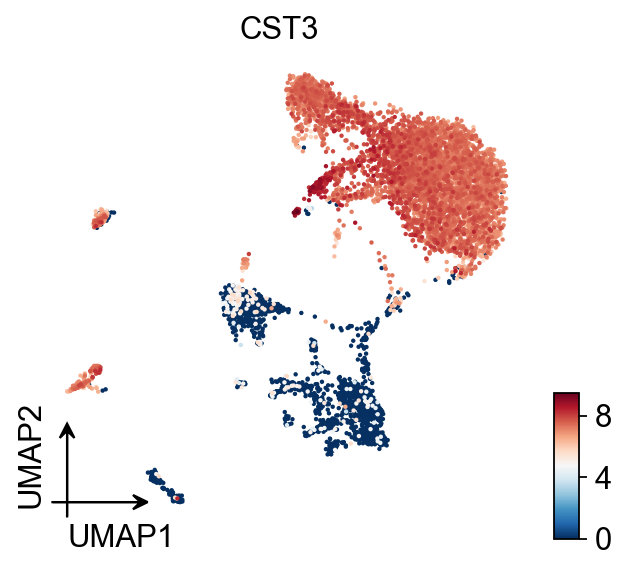

In [15]:
ov.pl.umap(adata,color='CST3')

### MDE

To visualize the PCA’s embeddings, we use the `pymde` package wrapper in omicverse. This is an alternative to UMAP that is GPU-accelerated.

In [16]:
ov.pp.mde(adata,embedding_dim=2,n_neighbors=15, basis='X_mde',
          n_pcs=50, use_rep='scaled|original|X_pca',)

🔍 MDE Dimensionality Reduction:
   Mode: cpu-gpu-mixed
   Embedding dimensions: 2
   Neighbors: 15
   Repulsive fraction: 0.7
   Using representation: scaled|original|X_pca
   Principal components: 50

Using CUDA device: NVIDIA H100 80GB HBM3
✅ Using built-in torch_pca for GPU-accelerated PCA
   🔍 Computing k-nearest neighbors graph...


   🔍 Creating MDE embedding...


   🔍 Optimizing embedding...




✅ MDE Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 7,677 cells × 2 dimensions
   ✓ Runtime: 3.71s
   ✓ Results added to AnnData object:
     • 'X_mde': MDE coordinates (adata.obsm)
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)


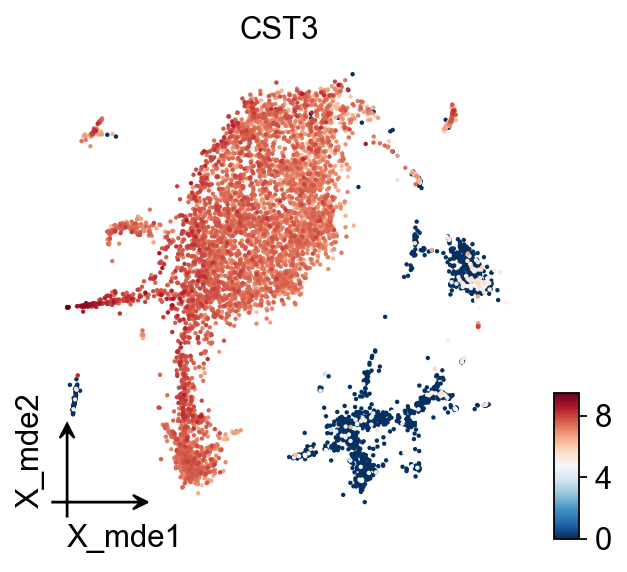

In [17]:
ov.pl.embedding(adata,
                basis='X_mde',
                color='CST3',
                frameon='small')

### TSNE

In [18]:
%%time
ov.pp.tsne(adata,use_rep='scaled|original|X_pca')

⚙️ Using torch CPU/GPU mixed mode to calculate t-SNE...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA H100 80GB HBM3
    ------------------------------ 2329/81559 MiB (2.9%)

🔍 t-SNE Dimensionality Reduction:
   Mode: cpu-gpu-mixed
   Components: 2
   Perplexity: 30
   Learning rate: 1000
   🔍 Computing t-SNE with scikit-learn...
   💡 Using scikit-learn TSNE implementation



✅ t-SNE Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 7,677 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_tsne': t-SNE coordinates (adata.obsm)
     • 'tsne': t-SNE parameters (adata.uns)

╭─ SUMMARY: tsne ────────────────────────────────────────────────────╮
│  Duration: 71.3102s                                                │
│  Shape:    7,677 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ tsne                                                 │
│           │ └─ params: {'perplexity': 30, 'early_exaggeration': 12, 'l...│
│                                                                    │
│  ● OBSM   │ ✚ X_tsne (array, 7677x2)                               │
│                                             

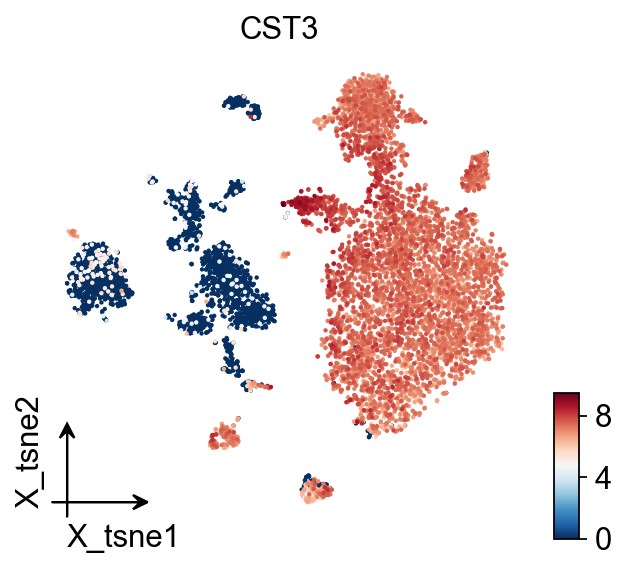

In [19]:
ov.pl.embedding(
    adata,
    basis='X_tsne',
    color='CST3',
    frameon='small'
)

### SUDE

SUDE, a scalable manifold learning method that uses uniform landmark sampling and constrained embedding to preserve both global structure and cluster separability, outperforming t-SNE, UMAP, and related methods across synthetic, real-world, and biomedical datasets.

Cite: Peng, D., Gui, Z., Wei, W. et al. Sampling-enabled scalable manifold learning unveils the discriminative cluster structure of high-dimensional data. Nat Mach Intell (2025). https://doi.org/10.1038/s42256-025-01112-9

In [ ]:
%%time
ov.pp.sude(adata,use_rep='scaled|original|X_pca')

In [ ]:
ov.pl.embedding(adata,
                basis='X_sude',
                color='CST3',
                frameon='small')

## Score cell cyle

In OmicVerse, we store both G1M/S and G2M genes into the function (both human and mouse), so you can run cell cycle analysis without having to manually enter cycle genes!

In [20]:
adata_raw=adata.raw.to_adata()
ov.pp.score_genes_cell_cycle(adata_raw,species='human')


╭─ SUMMARY: score_genes_cell_cycle ──────────────────────────────────╮
│  Duration: 0.4943s                                                 │
│  Shape:    7,677 x 20,050 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ G2M_score (float)                                    │
│           │ ✚ S_score (float)                                      │
│           │ ✚ phase (str)                                          │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_mde converted to MDE to visualize and saved to adata.obsm['MDE']
if you want to use X_mde, please set convert=False


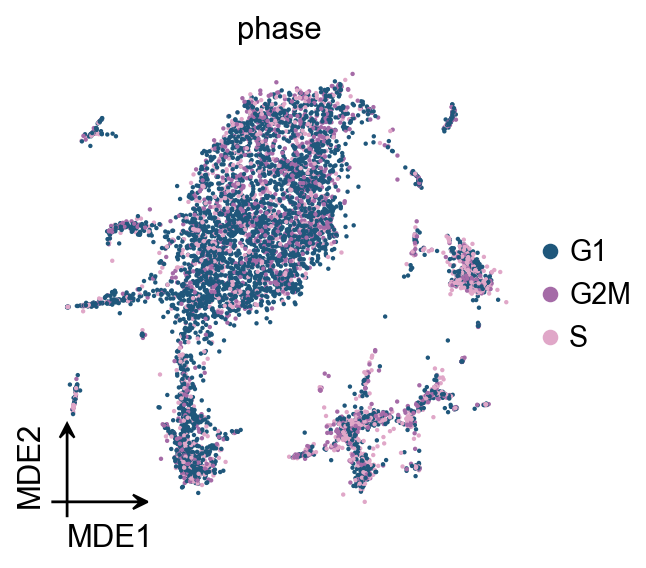

In [21]:
ov.pl.mde(adata_raw,color='phase')

## Clustering the neighborhood graph

As with Seurat and many other frameworks, we recommend the Leiden graph-clustering method (community detection based on optimizing modularity) by Traag *et al.* (2018). Note that Leiden clustering directly clusters the neighborhood graph of cells, which we already computed in the previous section.

In [22]:
ov.pp.leiden(adata,resolution=1)

⚙️ Using torch CPU/GPU mixed mode to calculate Leiden...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA H100 80GB HBM3
    ------------------------------ 2329/81559 MiB (2.9%)
running Leiden clustering


    finished (0.31s)
    found 20 clusters and added
    'leiden', the cluster labels (adata.obs, categorical)

╭─ SUMMARY: leiden ──────────────────────────────────────────────────╮
│  Duration: 0.36s                                                   │
│  Shape:    7,677 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ leiden (category)                                    │
│                                                                    │
│  ● UNS    │ ✚ leiden                                               │
│           │ └─ params: {'resolution': 1, 'random_state': 0, 'n_iterati...│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


### Picking a Leiden resolution automatically

Choosing the resolution by hand is fine for an exploratory pass, but for reproducible pipelines `ov.single.auto_resolution` will select it for you using **null-adjusted bootstrap-ARI stability** ([Lange, Roth, Braun & Buhmann, *Neural Computation* 2004](https://doi.org/10.1162/089976604773717621)). For each candidate resolution it:

1. Runs Leiden on the full graph → reference labels.
2. Re-runs Leiden on `n_subsamples` random subsamples.
3. Scores each bootstrap by ARI vs the reference labels restricted to the subsample → `stability_real(r)`.
4. Repeats the same PCA → kNN-graph → bootstrap pipeline on a **per-gene-permuted null** (no cell-cell structure left) → `stability_null(r)`.
5. Picks `argmax(stability_real - stability_null)` subject to `n_clusters >= min_clusters`.

The null subtraction is what makes the algorithm pick a *biologically meaningful* resolution rather than the one that happens to slice the data into the most reproducible tiny clusters.

In [23]:
# Suppress per-leiden SUMMARY boxes — only show the final scores table.
import io, contextlib
with contextlib.redirect_stdout(io.StringIO()):
    adata, best, scores = ov.single.auto_resolution(
        adata,
        resolutions=[0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5],
        n_subsamples=5,
        n_null_subsamples=3,
        random_state=0,
        key_added='leiden_auto',
    )
print(f'autoResolution chose r={best}')
scores

autoResolution chose r=0.4


            n_clusters  stability_real  stability_null  excess_stability  \
resolution                                                                 
0.2                  8        0.959048        1.000000         -0.040952   
0.4                 11        0.691287        0.297422          0.393865   
0.6                 14        0.531035        0.619179         -0.088143   
0.8                 15        0.796962        0.589003          0.207959   
1.0                 20        0.588284        0.484690          0.103594   
1.2                 22        0.622066        0.467593          0.154473   
1.5                 25        0.591450        0.293998          0.297452   

            std_real  
resolution            
0.2         0.013257  
0.4         0.043664  
0.6         0.022619  
0.8         0.045211  
1.0         0.039070  
1.2         0.030341  
1.5         0.019143  

The selection curve makes the choice explicit: where the **null** (grey) saturates near 1.0 the resolution is rejected (one or two clusters are trivially perfectly stable), and where it collapses the **excess** (terracotta) becomes meaningful. The chosen `r` is the peak of the excess curve.

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0
✅ plot_set complete.



<Axes: title={'center': 'Resolution-stability curve (Lange et al. 2004)'}, xlabel='Leiden resolution', ylabel='stability (mean bootstrap ARI)'>

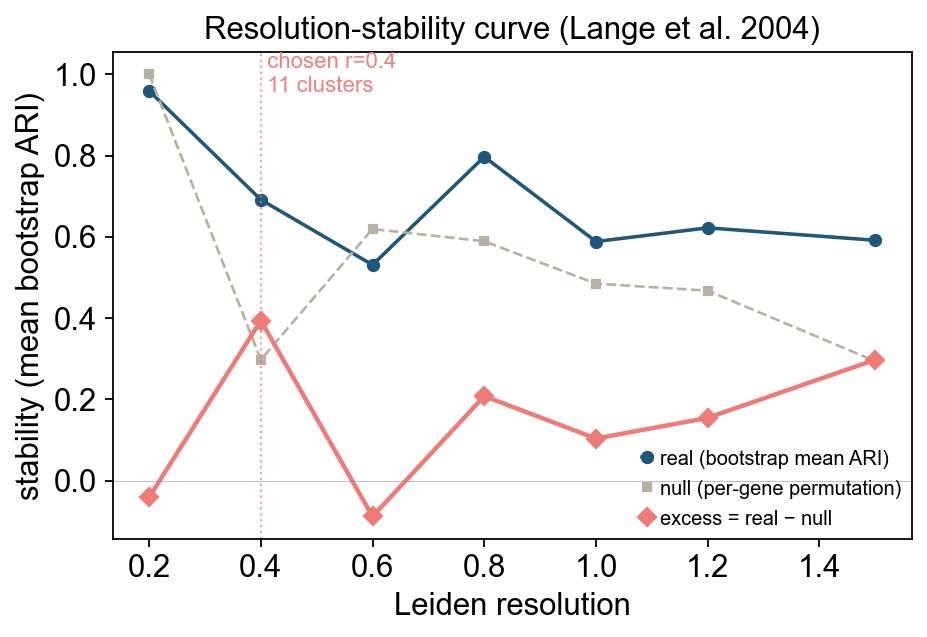

In [24]:
ov.style()
ov.pl.auto_resolution_curve(adata)

Project the auto-selected clusters back onto the embedding alongside the dataset's own `predicted_celltype` annotation — that's why pbmc8k is a useful validation target: it ships with curated cell-type labels we can score against. ARI/NMI between `leiden_auto` and `predicted_celltype` quantify the match.

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0
✅ plot_set complete.

ARI(leiden_auto, predicted_celltype) = 0.830
NMI(leiden_auto, predicted_celltype) = 0.807
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


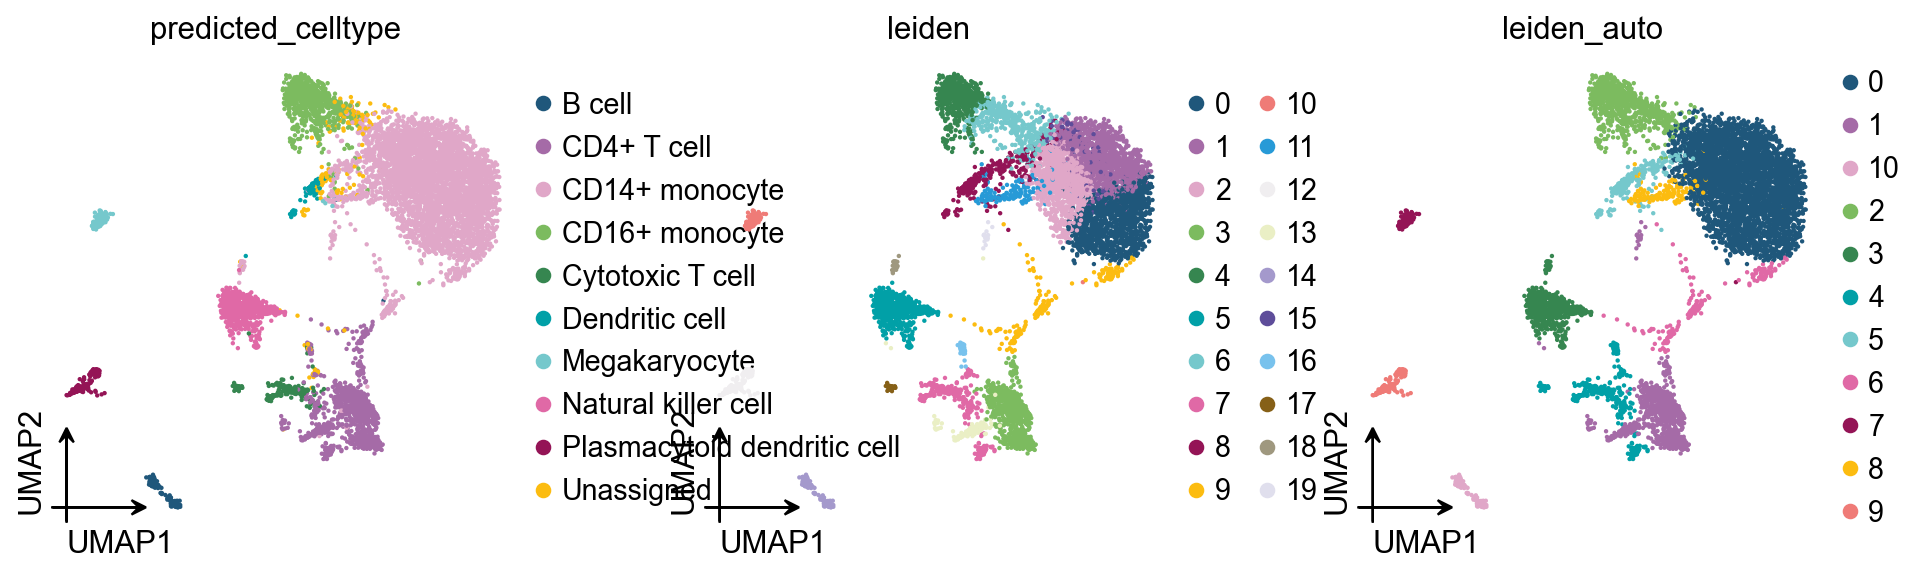

In [25]:
ov.style()
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
ari = adjusted_rand_score(
    adata.obs['predicted_celltype'], adata.obs['leiden_auto'])
nmi = normalized_mutual_info_score(
    adata.obs['predicted_celltype'], adata.obs['leiden_auto'])
print(f'ARI(leiden_auto, predicted_celltype) = {ari:.3f}')
print(f'NMI(leiden_auto, predicted_celltype) = {nmi:.3f}')
ov.pl.umap(
    adata,
    color=['predicted_celltype', 'leiden', 'leiden_auto'],
    frameon='small',
    palette=ov.pl.sc_color,
    ncols=3,
)

We redesigned the visualisation of embedding to distinguish it from scanpy's embedding by adding the parameter `fraemon='small'`, which causes the axes to be scaled with the colourbar

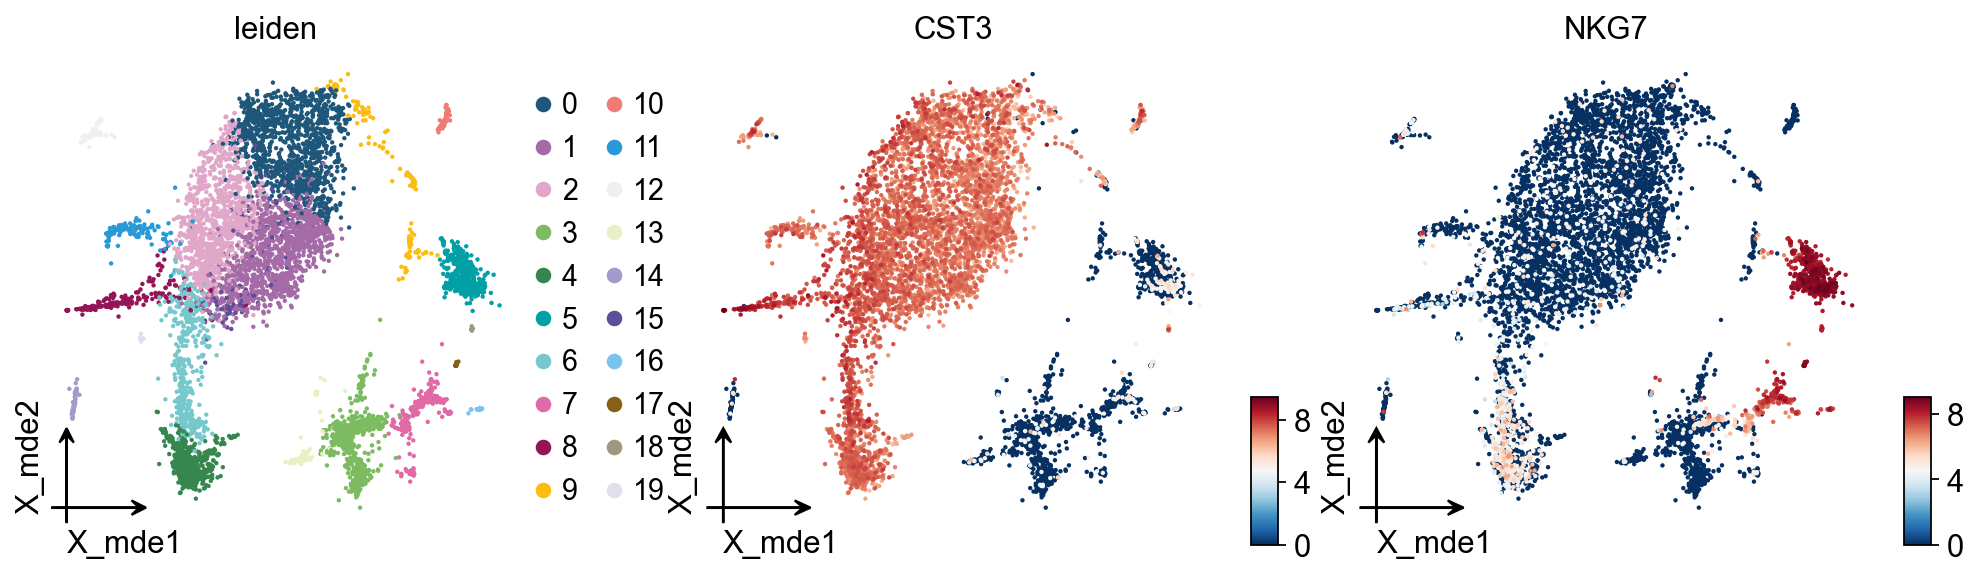

In [26]:
ov.pl.embedding(
    adata,
    basis='X_mde',
    color=['leiden', 'CST3', 'NKG7'],
    frameon='small',
    palette=ov.pl.sc_color
)

We also provide a boundary visualisation function `ov.utils.plot_ConvexHull` to visualise specific clusters.

Arguments: 
- color: if None will use the color of clusters
- alpha: default is 0.2

leiden_colors


<Axes: title={'center': 'leiden'}, xlabel='X_mde1', ylabel='X_mde2'>

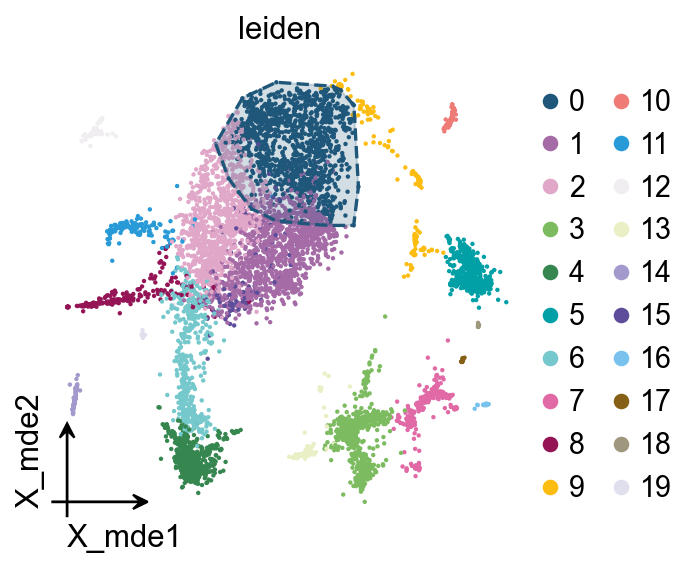

In [27]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots( figsize = (4,4))

ov.pl.embedding(adata,
                basis='X_mde',
                color=['leiden'],
                frameon='small',
                show=False,
                ax=ax)

ov.pl.ConvexHull(adata,
                basis='X_mde',
                cluster_key='leiden',
                hull_cluster='0',
                ax=ax)


If you have too many labels, e.g. too many cell types, and you are concerned about cell overlap, then consider trying the `ov.utils.gen_mpl_labels` function, which improves text overlap.
In addition, we make use of the `patheffects` function, which makes our text have outlines

- adjust_kwargs: it could be found in package `adjusttext`
- text_kwargs: it could be found in class `plt.texts`

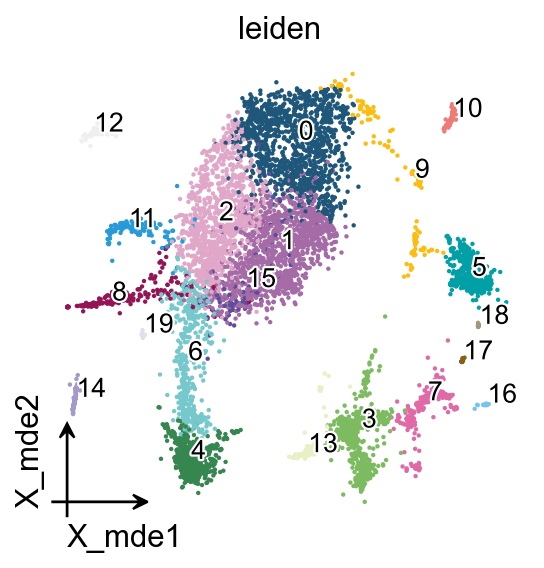

In [28]:
from matplotlib import patheffects
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,4))

ov.pl.embedding(
    adata,
    basis='X_mde',
    color=['leiden'],
    show=False, legend_loc=None, add_outline=False, 
    frameon='small',legend_fontoutline=2,ax=ax
)

ov.utils.gen_mpl_labels(
    adata,
    'leiden',
    exclude=("None",),  
    basis='X_mde',
    ax=ax,
    adjust_kwargs=dict(arrowprops=dict(arrowstyle='-', color='black')),
    text_kwargs=dict(fontsize= 12 ,weight='bold',
                     path_effects=[patheffects.withStroke(linewidth=2, foreground='w')] ),
)

In [29]:
marker_genes = ['IL7R', 'CD79A', 'MS4A1', 'CD8A', 'CD8B', 'LYZ', 'CD14',
                'LGALS3', 'S100A8', 'GNLY', 'NKG7', 'KLRB1',
                'FCGR3A', 'MS4A7', 'FCER1A', 'CST3', 'PPBP']

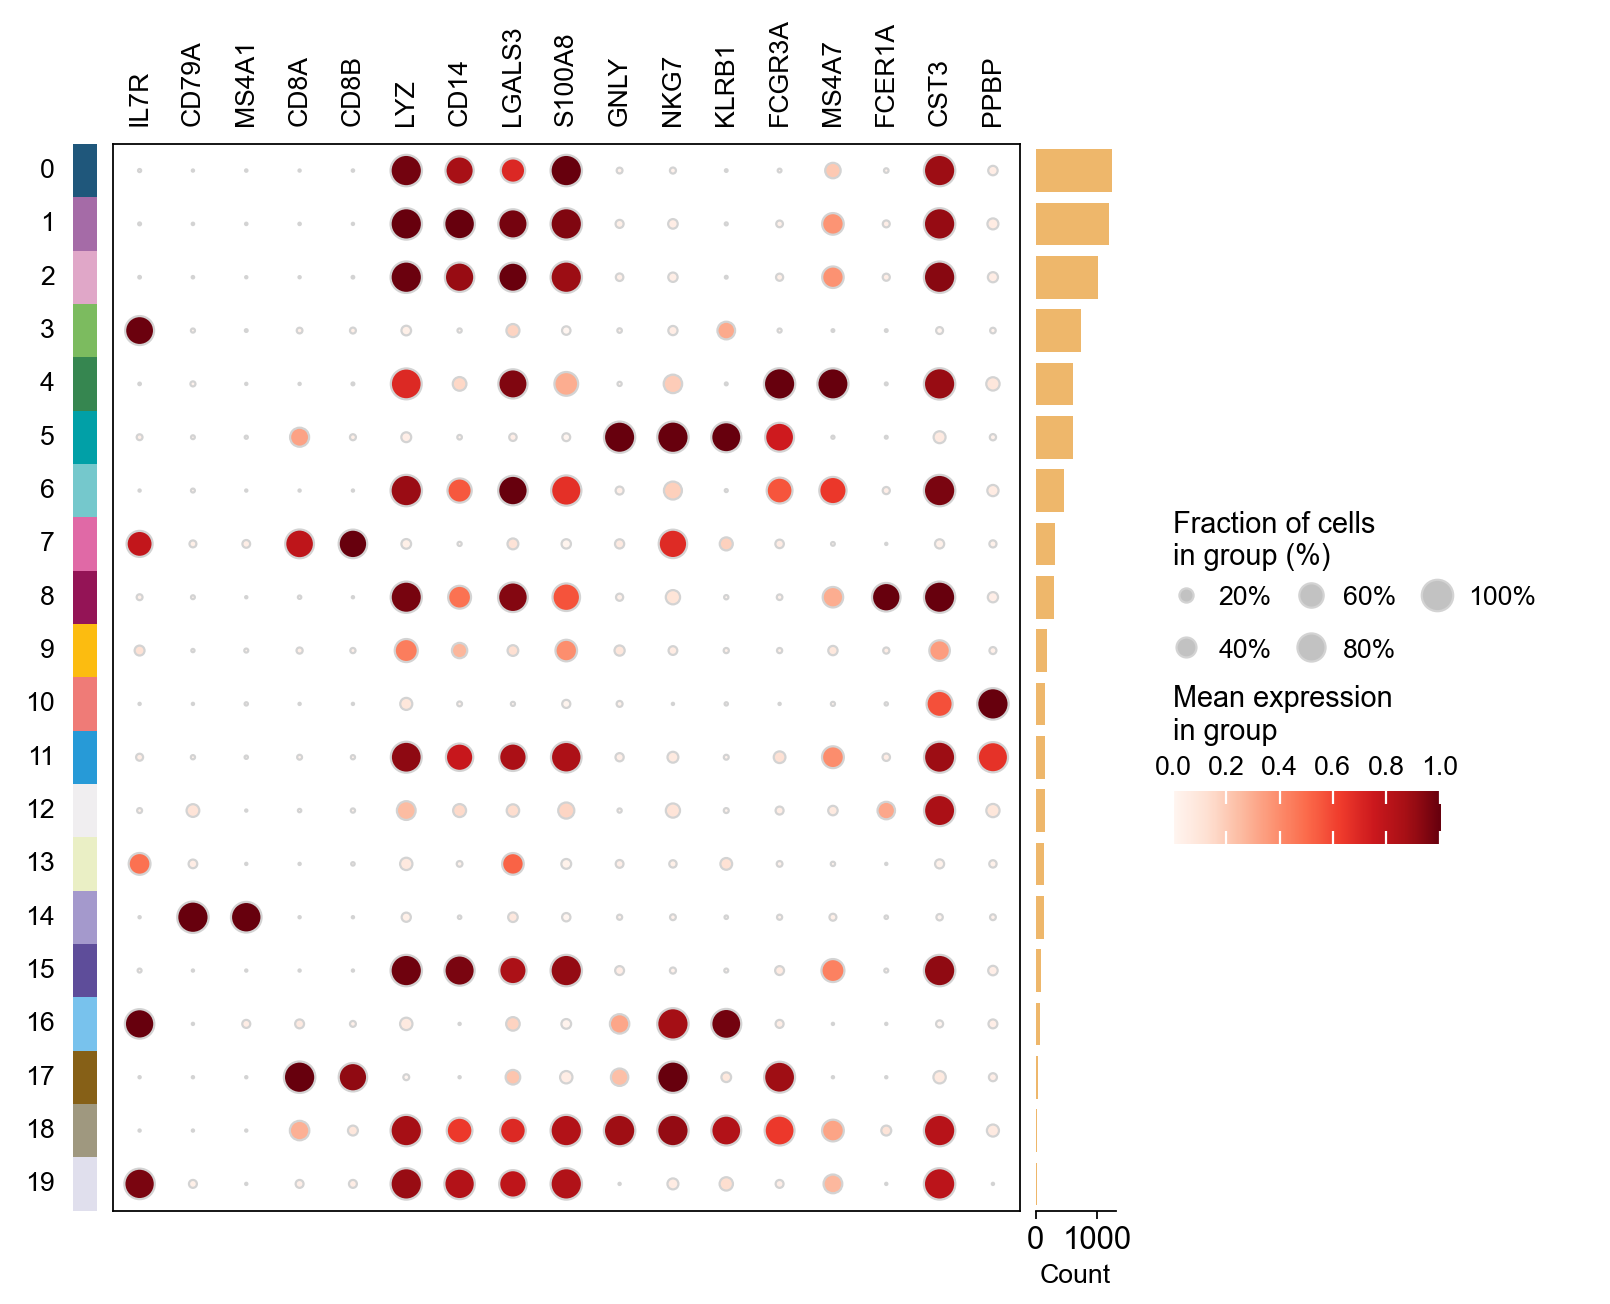

In [30]:
ov.pl.dotplot(adata, marker_genes, groupby='leiden',
             standard_scale='var');

In [31]:
adata.write('data/pbmc_preprocessed_markers.h5ad')

## Finding marker genes

Let us compute a ranking for the highly differential genes in each cluster. For this, by default, the .raw attribute of AnnData is used in case it has been initialized before. The simplest and fastest method to do so is the t-test.

In [32]:
%%time
ov.single.find_markers(
    adata,
    groupby='leiden', 
    method='wilcoxon',#t-test
    key_added="rank_genes_groups",
    pts=True,
)

🔍 Finding marker genes | method: wilcoxon | groupby: leiden | n_groups: 20 | n_genes: 50


✅ Done | 20 groups × 50 genes | corr: benjamini-hochberg | stored in adata.uns['rank_genes_groups']
CPU times: user 10.2 s, sys: 451 ms, total: 10.7 s
Wall time: 10.7 s


In [33]:
ov.single.get_markers(
    adata,
    groups=['0'],
    key = "rank_genes_groups",
)

  group  rank    names     scores  logfoldchanges          pvals  \
0     0     1   S100A8  44.998802        6.590432   0.000000e+00   
1     0     2   S100A9  43.323971        6.051874   0.000000e+00   
2     0     3  S100A12  39.206455        5.511002   0.000000e+00   
3     0     4   S100A6  35.015156        2.022107  1.322866e-268   
4     0     5     VCAN  34.773167        4.803245  6.190950e-265   
5     0     6      FOS  32.592533        2.474985  5.232700e-233   
6     0     7    CSF3R  32.450523        3.958353  5.325109e-231   
7     0     8     TSPO  31.904837        2.399369  2.287862e-223   
8     0     9  ATP5F1E  28.948526        1.022710  2.928787e-184   
9     0    10     NCF1  28.933880        3.356097  4.476989e-184   

       pvals_adj  pct_group  pct_rest  
0   0.000000e+00   1.000000  0.589580  
1   0.000000e+00   1.000000  0.644012  
2   0.000000e+00   0.937450  0.417729  
3  5.304694e-265   1.000000  0.929705  
4  2.068809e-261   0.967923  0.515241  
5  1.311445

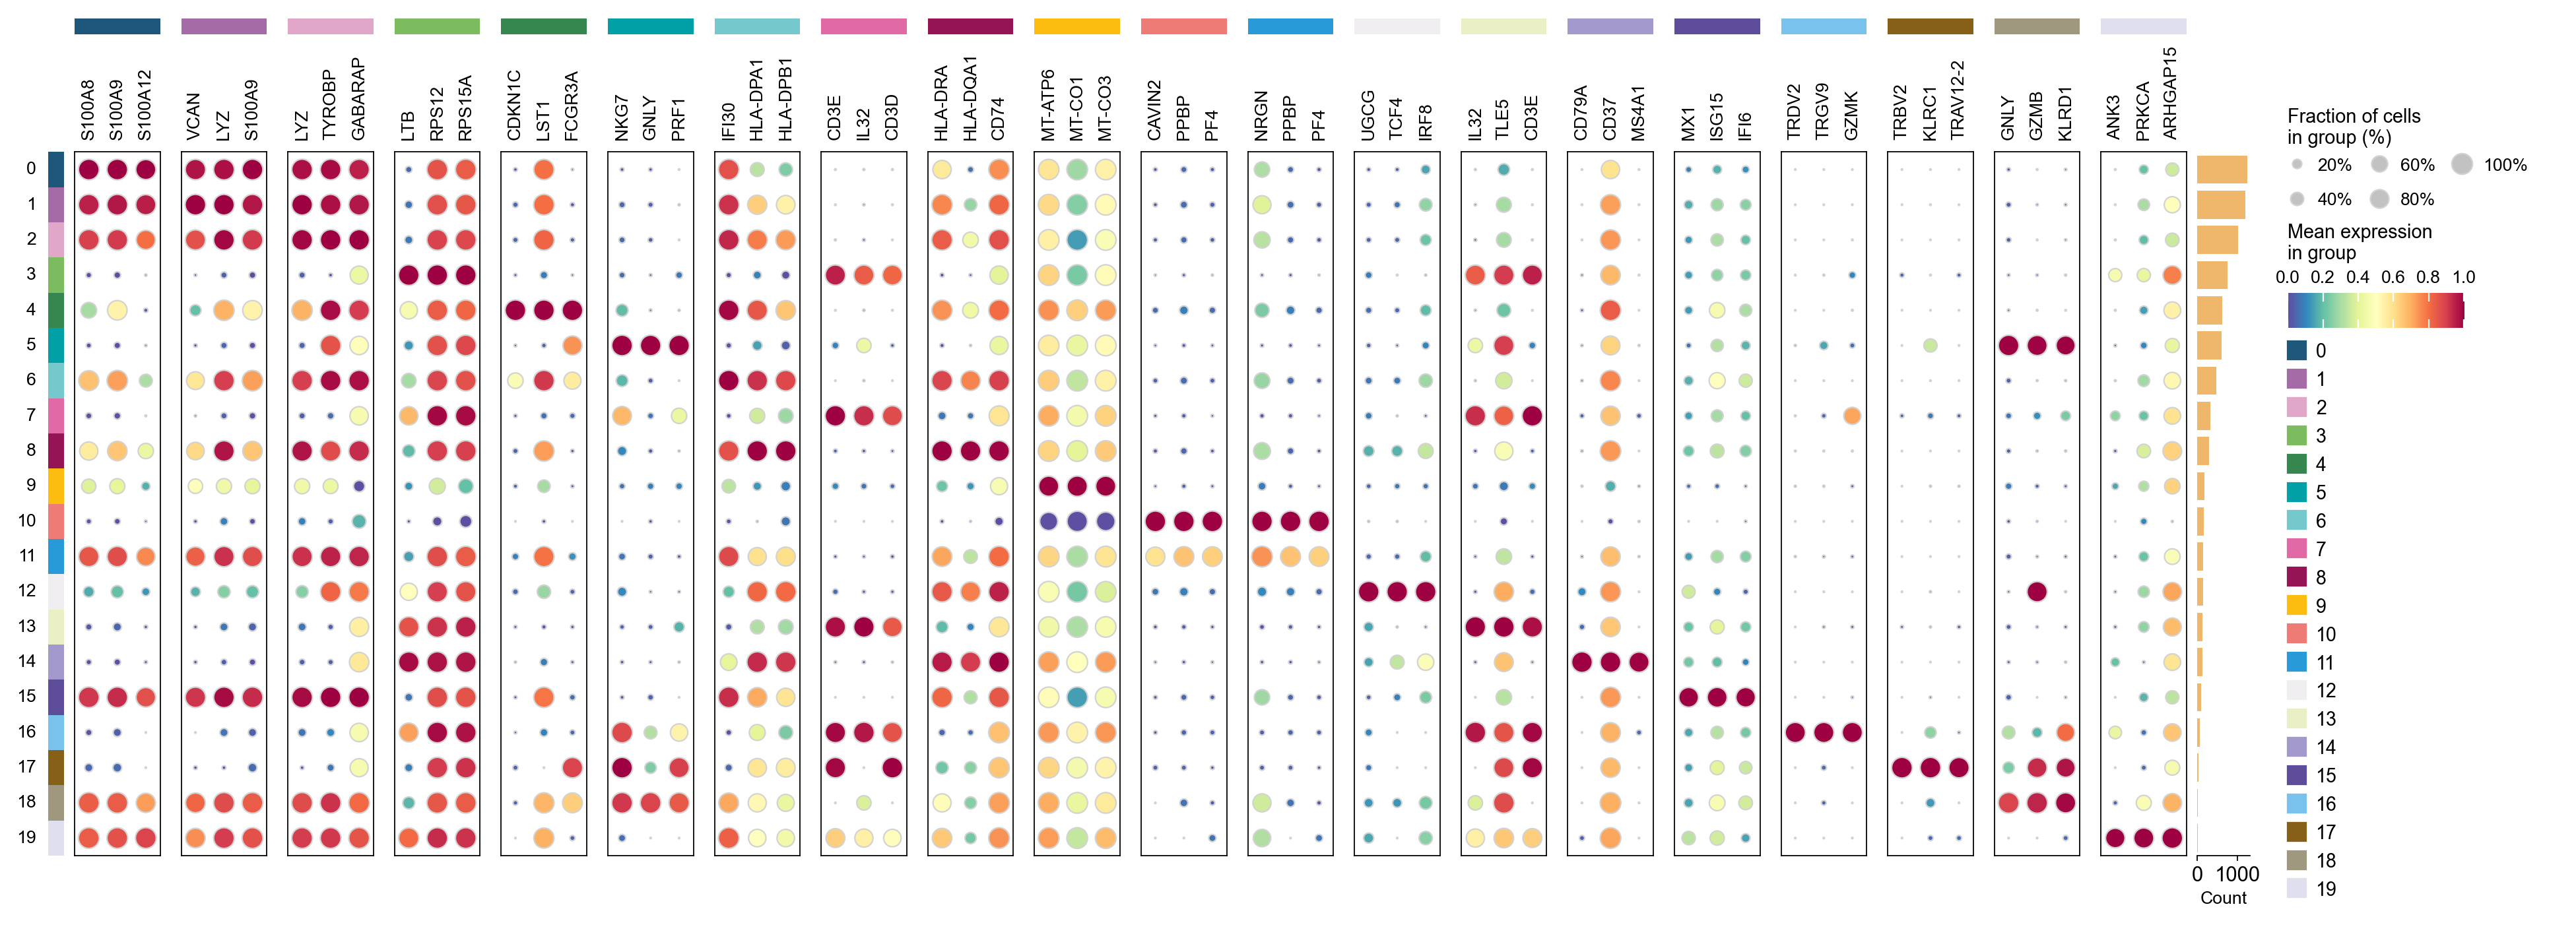

In [34]:
ov.pl.markers_dotplot(
    adata, groupby='leiden', 
    n_genes=3,
    key="rank_genes_groups",
)

cosg is also considered to be a better algorithm for finding marker genes. Here, omicverse provides the calculation of cosg

Paper: [Accurate and fast cell marker gene identification with COSG](https://academic.oup.com/bib/advance-article-abstract/doi/10.1093/bib/bbab579/6511197?redirectedFrom=fulltext)

Code: https://github.com/genecell/COSG


In [35]:
%%time
ov.single.find_markers(
    adata,
    groupby='leiden', 
    method='cosg',#t-test
    key_added="leiden_cosg",
    pts=True,
)

🔍 Finding marker genes | method: cosg | groupby: leiden | n_groups: 20 | n_genes: 50


**finished identifying marker genes by COSG**


✅ Done | 20 groups × 50 genes | stored in adata.uns['leiden_cosg']
CPU times: user 2.46 s, sys: 9.82 ms, total: 2.47 s
Wall time: 2.47 s


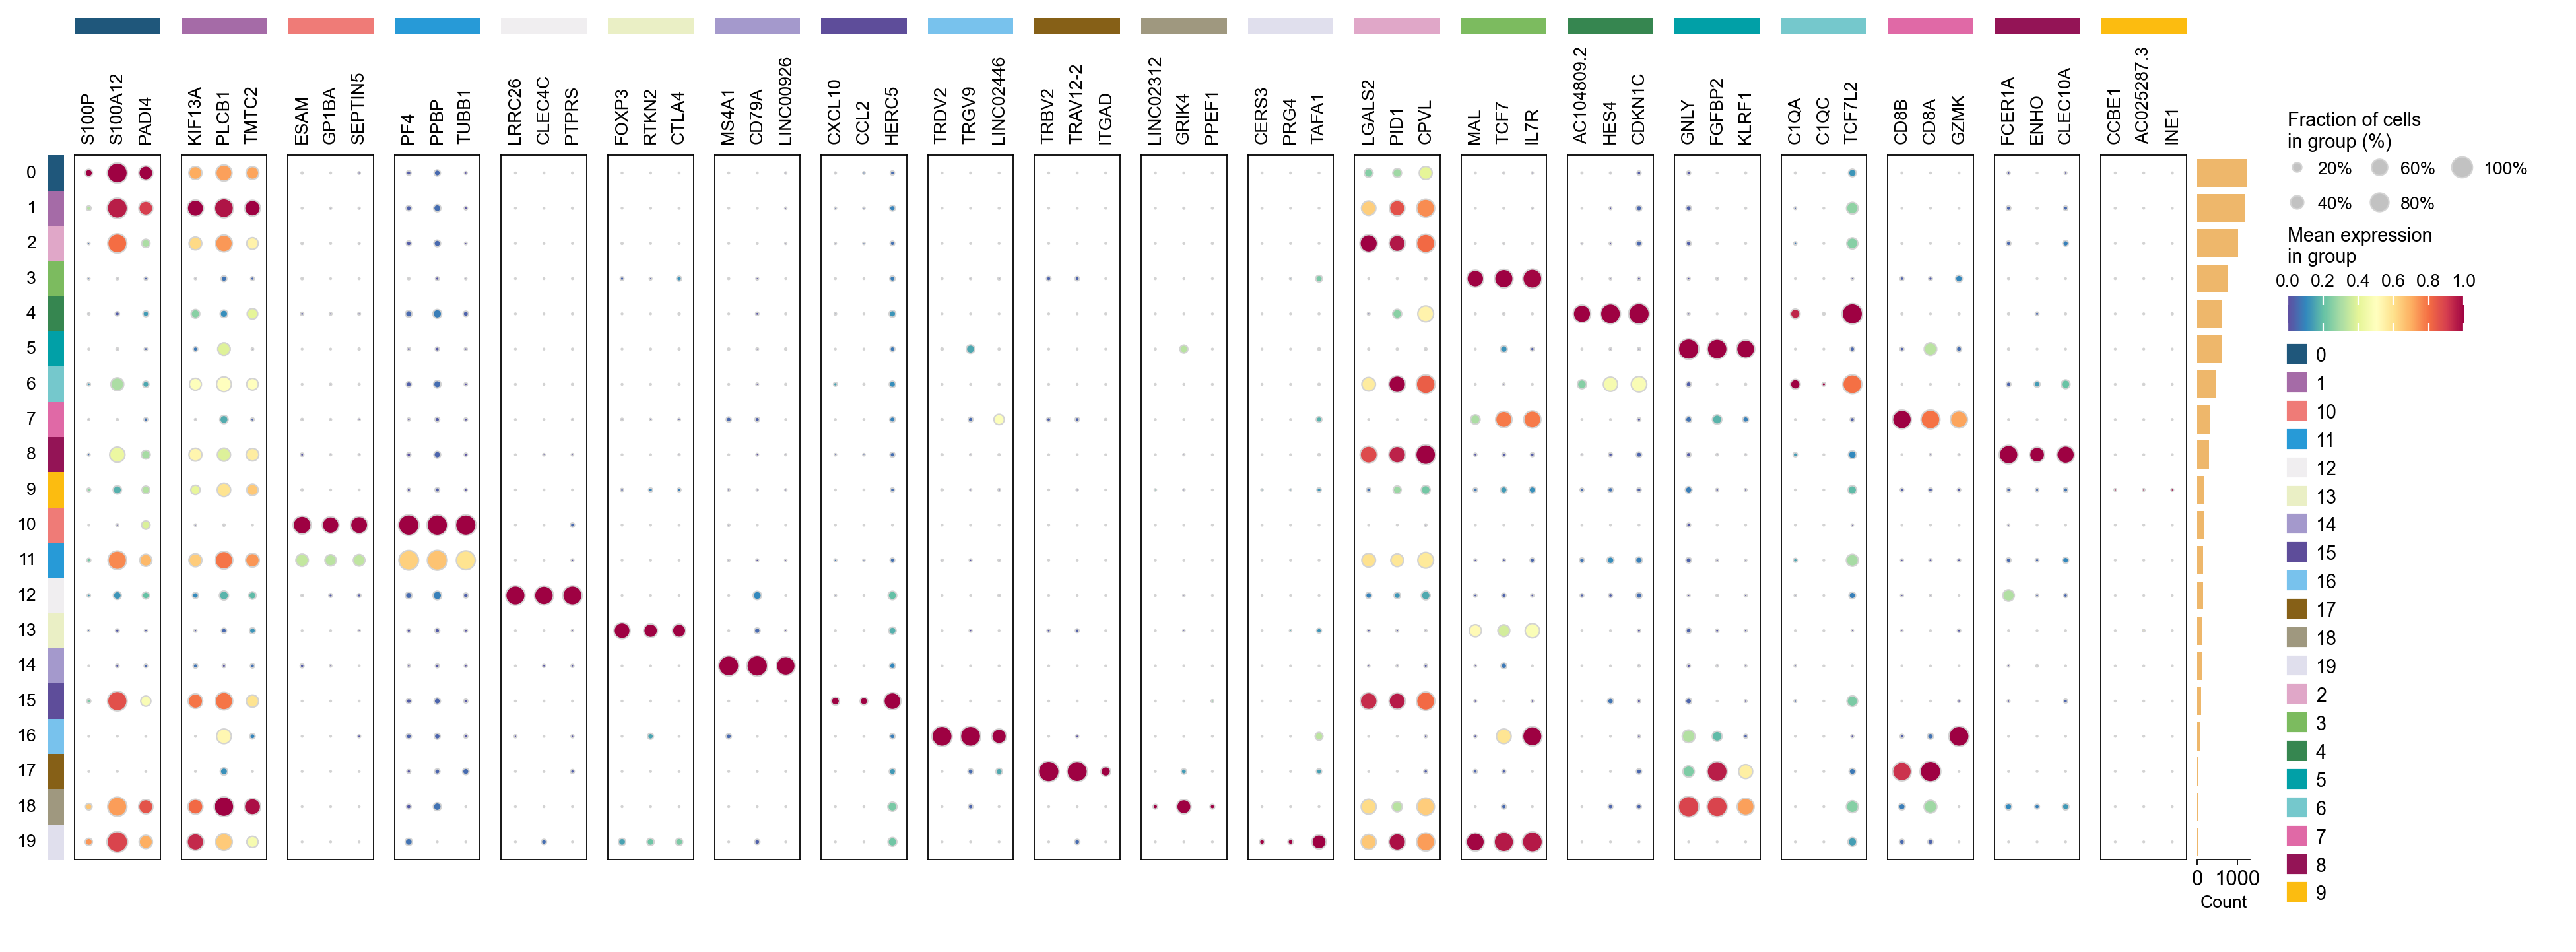

In [36]:
ov.pl.markers_dotplot(
    adata, groupby='leiden', 
    n_genes=3,
    key="leiden_cosg",
)

In [37]:
ov.single.get_markers(
    adata,
    n_genes=20,
    key = "rank_genes_groups",
)

    group  rank    names     scores  logfoldchanges          pvals  \
0       0     1   S100A8  44.998802        6.590432   0.000000e+00   
1       0     2   S100A9  43.323971        6.051874   0.000000e+00   
2       0     3  S100A12  39.206455        5.511002   0.000000e+00   
3       0     4   S100A6  35.015156        2.022107  1.322866e-268   
4       0     5     VCAN  34.773167        4.803245  6.190950e-265   
..    ...   ...      ...        ...             ...            ...   
395    19    16      MAL   4.574203        5.732344   4.780368e-06   
396    19    17   INPP4B   4.555688        6.206233   5.221436e-06   
397    19    18   ABLIM1   4.504581        5.630849   6.650395e-06   
398    19    19  TNFAIP8   4.450352        4.367236   8.572962e-06   
399    19    20   TNRC6B   4.392069        4.240511   1.122768e-05   

         pvals_adj  pct_group  pct_rest  
0     0.000000e+00   1.000000  0.589580  
1     0.000000e+00   1.000000  0.644012  
2     0.000000e+00   0.937450  0.

In [38]:
ov.single.get_markers(
    adata,
    n_genes=5,
    key = "rank_genes_groups",
    return_type='dict'
)

{'0': ['S100A8', 'S100A9', 'S100A12', 'S100A6', 'VCAN'],
 '1': ['VCAN', 'LYZ', 'S100A9', 'FOS', 'CD14'],
 '2': ['LYZ', 'TYROBP', 'GABARAP', 'LGALS2', 'GSTP1'],
 '3': ['LTB', 'RPS12', 'RPS15A', 'RPS25', 'RPS27'],
 '4': ['CDKN1C', 'LST1', 'FCGR3A', 'SMIM25', 'MS4A7'],
 '5': ['NKG7', 'GNLY', 'PRF1', 'CTSW', 'CST7'],
 '6': ['IFI30', 'HLA-DPA1', 'HLA-DPB1', 'COTL1', 'HLA-DRA'],
 '7': ['CD3E', 'IL32', 'CD3D', 'CD8B', 'RPS3'],
 '8': ['HLA-DRA', 'HLA-DQA1', 'CD74', 'HLA-DRB1', 'HLA-DPB1'],
 '9': ['MT-ATP6', 'MT-CO1', 'MT-CO3', 'MT-CO2', 'MT-CYB'],
 '10': ['CAVIN2', 'PPBP', 'PF4', 'GNG11', 'NRGN'],
 '11': ['NRGN', 'PPBP', 'PF4', 'TUBB1', 'CAVIN2'],
 '12': ['UGCG', 'TCF4', 'IRF8', 'LILRA4', 'SERPINF1'],
 '13': ['IL32', 'TLE5', 'CD3E', 'CD3D', 'FCMR'],
 '14': ['CD79A', 'CD37', 'MS4A1', 'CD74', 'BANK1'],
 '15': ['MX1', 'ISG15', 'IFI6', 'APOBEC3A', 'TYMP'],
 '16': ['TRDV2', 'TRGV9', 'GZMK', 'CCL5', 'IL32'],
 '17': ['TRBV2', 'KLRC1', 'TRAV12-2', 'CD8A', 'CD3D'],
 '18': ['GNLY', 'GZMB', 'KLRD1', 'NKG